In [1]:
import sys
import os
sys.path.insert(0, "/global/u1/p/prakharb/desilike")
#sys.path.insert(0, "/global/u1/p/prakharb/desilike")
#sys.path.insert(0, "/global/u1/p/prakharb/cosmoprimo")
import desilike, inspect
print(inspect.getfile(desilike))


import numpy as np
import matplotlib.pyplot as plt
from desilike.theories.galaxy_clustering import LPTVelocileptorsTracerPowerSpectrumMultipoles, REPTVelocileptorsTracerPowerSpectrumMultipoles,  DirectPowerSpectrumTemplate, ShapeFitPowerSpectrumTemplate
from desilike.theories.galaxy_clustering.full_shape import FOLPSv2TracerPowerSpectrumMultipoles, FOLPSv2TracerBispectrumMultipoles
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable 
from desilike.observables import ObservableCovariance
from desilike.emulators import EmulatedCalculator, Emulator, TaylorEmulatorEngine
from desilike.likelihoods import ObservablesGaussianLikelihood, SumLikelihood
from desilike.theories import Cosmoprimo
from cosmoprimo.fiducial import DESI
from desilike import setup_logging
from desilike.parameter import Parameter, ParameterPrior
import argparse
import sys, os, shutil
import time
import emcee
import numpy as np
from schwimmbad import MPIPool
from datetime import datetime
from desilike_mcmc.mike_data_tools import *


/global/u1/p/prakharb/desilike/desilike/__init__.py


In [13]:
cosmo = Cosmoprimo(engine='class')
cosmo.init.params['H0'] = dict(derived=True)
cosmo.init.params['Omega_m'] = dict(derived=True)
cosmo.init.params['sigma8_m'] = dict(derived=True) 
#cosmo.init.params['fR0'] = dict(derived=False, latex ='f_{R0}')
fiducial = DESI() #fiducial cosmology
0.06/93.14

0.0006441915396177796

In [2]:




# In[ ]:


######### Settings #########

#model: LCDM or HS
model = 'LCDM'

#Put 'True' to resume chain. 'False' to start from 0 steps
restart_chain = False
#Biasing and EFT parametrization: 'physical' or 'default' (non-physical)
prior_basis = 'standard' #Prior to be used 

kr_max = 0.201
kr_b0_max = 0.15
kr_b2_max = 0.12


#width for EFT and SN paramss
width_EFT = 12.5
width_SN0 = 2.0
width_SN2 = 5.0

pt_model = "folps"  # Change this to "rept_velocileptors" or "pybird" as needed

sampler = 'cobaya'

set_emulator = True

GR_criteria = 0.01  # R - 1 < GR_criteria 


# Argument parser
#parser = argparse.ArgumentParser(description="Run MCMC analysis with different tracers")
#parser.add_argument("--tracers", nargs="+", required=True, help="List of tracers to use")
#args = parser.parse_args()


# List of tracers
# tracers = ['BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO']  # Add more tracers as needed
tracers = ['LRG2']
#tracers = args.tracers
all_tracers = {'BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO'}

if set(tracers) == all_tracers:
    tracers_str = "all"
else:
    tracers_str = "+".join(tracers)

chain_name = f'chains/MCMC-fs_abacus2gen_folpsv2_bispectrum_test_0.20_0.14_var_nuis_uniform_0.2cov'
if not set_emulator:
    chain_name += '_noemu'
#print(chain_name)



from desilike import ParameterCollection

def make_params(prior_basis, width_EFT, width_SN0, width_SN2):
    params = ParameterCollection()

    if prior_basis == 'physical':
        # Shared params
        params['b1p'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2p'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bsp'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': 20}}

        # PS-only
        params['alpha0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha4p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['sn0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        params['sn2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}

        # BS-only → if physical, no c1,c2,Pshot,Bshot,X_FoG_b

    else:
        # Shared params
        params['b1'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bs'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['b3'] = {'fixed':True}

        # PS-only
        # params['alpha0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        # params['alpha2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        # params['alpha4'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        # params['sn0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        # params['sn2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}
        params['alpha0'] = {'value':0.0,'fixed':True}
        params['alpha2'] = {'value':0.0,'fixed':True}
        params['alpha4'] = {'value':0.0,'fixed':True}
        params['sn0'] = {'value':0.0,'fixed':True}
        params['sn2'] = {'value':0.0,'fixed':True}
        # params['X_FoG_p'] = {'prior': {'dist':'uniform','limits': [0, 10]}}  # fixed in your snippet
        params['X_FoG_p'] = {'fixed':True}  # fixed in your snippet

        # BS-only
        params['c1'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['c2'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['Pshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['Bshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['X_FoG_b'] = {'prior': {'dist':'uniform','limits': [0, 15]}}

    return params




#Define a cosmology to get sigma_8, Omega_m and fR0
cosmo = Cosmoprimo(engine='class')
cosmo.init.params['H0'] = dict(derived=True)
cosmo.init.params['Omega_m'] = dict(derived=True)
cosmo.init.params['sigma8_m'] = dict(derived=True) 
#cosmo.init.params['fR0'] = dict(derived=False, latex ='f_{R0}')
fiducial = DESI() #fiducial cosmology

#Update cosmo priors
for param in ['n_s', 'h','omega_cdm', 'omega_b', 'logA', 'tau_reio']:
    cosmo.params[param].update(fixed = False)
    if param == 'tau_reio':
        cosmo.params[param].update(fixed = True)
    if param == 'n_s':
            cosmo.params[param].update(fixed = True)
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.9649, 'scale': 0.042})
    if param == 'omega_b':
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02218, 'scale': 0.00055})
            cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02237, 'scale': 0.00037})  #From simulations
    if param == 'h':
            cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.5,0.9]})
    if param == 'omega_cdm':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.05, 0.2]})
    #if param == 'm_ncdm':
        #cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.0, 5]})
    if param == 'logA':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [2.0, 4.0]})
    


#Define tracer types and their corresponding redshifts
all_tracer_params = {
    'BGS': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4.npy'
    },
    'LRG1': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.4-0.6.npy'
    },
    'LRG2': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.6-0.8.npy'
    },
    'LRG3': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.8-1.1.npy'
    },
    'ELG': {
       'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_ELG_LOPnotqso_GCcomb_z1.1-1.6.npy'
    },
    'QSO': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_QSO_GCcomb_z0.8-2.1.npy'
    }
}  

all_tracer_redshifts = {
                        'BGS': 0.295,
                        'LRG1': 0.510,
                        'LRG2': 0.8,
                        'LRG3': 0.930,
                        'ELG': 1.317,
                        'QSO': 1.491
                        }

tracer_params = {index: all_tracer_params[tracer] for index, tracer in enumerate(tracers)}
tracer_redshifts = {tracer: all_tracer_redshifts[tracer] for tracer in tracers}


#Iterate over each tracer and create the corresponding theory object
# Theories container: dict of dicts
theories = {}

for tracer in tracers:
    z = tracer_redshifts[tracer]
    template = DirectPowerSpectrumTemplate(fiducial=fiducial, cosmo=cosmo, z=z)

    # PS theory selection
    if pt_model == "rept_velocileptors":
        ps_theory = REPTVelocileptorsTracerPowerSpectrumMultipoles(template=template,
                                                                   prior_basis=prior_basis)
    else:
        ps_theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template,
                                                         prior_basis=prior_basis)

    # BS theory always FOLPSv2 in your snippet
    bs_theory = FOLPSv2TracerBispectrumMultipoles(template=template,
                                                  prior_basis=prior_basis)

    # Store
    theories[tracer] = {"ps": ps_theory, "bs": bs_theory}

    # --- Update parameters ---
    params = make_params(prior_basis, width_EFT, width_SN0, width_SN2)
    for name, p in params.items():
        for comp in ["ps", "bs"]:
            if name in theories[tracer][comp].params:
                theories[tracer][comp].params[name].update(p)


    print("X_FoG_b=",params['X_FoG_b'].value)
    print("b3=",params['b3'].value)


        
    

    for param in ps_theory.all_params:
        print(param,':',ps_theory.all_params[param].prior)
    for param in bs_theory.all_params:
        print(param,':',bs_theory.all_params[param].prior)

#Define data vector and covariance using mike data tools

def load_data_vector_and_covariance():
    k_min=0.02
    k_max=0.201
    k_max_b0 = 0.15
    k_max_b2 = 0.12

    isP0, isP2, isP4 =True, True, False
    isB000, isB202 = True, True

    Vol=1

    tracer='LRG'
    z_str='z0.800'
    z_evaluation=0.8

    path_fits='chains/'

    now = datetime.now()
    tiempo=now.strftime("%m-%d-%Y-%H%M")

    name=f"c_FolpsD__{tracer}_z{z_evaluation:.3f}_Pkmax-{k_max:.3f}_B000kmax-{k_max_b0:.3f}_B202kmax-{k_max_b2:.3f}_bsfree"


    chains_filename = path_fits+name+".h5"
    copy_filename = path_fits+name+".py"
    print(chains_filename)
        

    # +
    k_data_2nd,pkl0_2nd_all,pkl2_2nd_all,a,B000_2nd_all,B202_2nd_all = ExtractDataAbacusSummit(tracer,z_str,
                                                                                            subtract_shot=True)

    Pk_0_2nd = np.mean(pkl0_2nd_all,axis = 0)
    Pk_2_2nd = np.mean(pkl2_2nd_all,axis = 0)
    B000_2nd = np.mean(B000_2nd_all,axis = 0)
    B202_2nd = np.mean(B202_2nd_all,axis = 0)

    # Read covariance

    k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks = ExtractDataEZmock(tracer,z_str)
    k_cov_all, mean_ezmocks_all, cov_array_all = covariance(k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks, Nscaling = Vol)



    pole_selection=[isP0, isP2, isP4,isB000, isB202]
    print(pole_selection)

    kmin_pk=0.02; kmax_pk=k_max
    kmin_bk=0.02; 
    ranges=[[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_bk,k_max_b0],[kmin_bk,k_max_b2]]

    mask=pole_k_selection(k_cov_all,pole_selection,ranges)
    #print(mask.shape)
    #print(mask)
    k_cov=k_cov_all[mask]

    #k_cov.shape
    k_points_pk = np.where((kmin_pk < k_data_2nd) & (k_data_2nd < kmax_pk)  & isP0)
    k_points_b0 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b0) & isB000)
    k_points_b2 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b2) & isB202)

    data = np.concatenate((Pk_0_2nd[k_points_pk],Pk_2_2nd[k_points_pk],
                        B000_2nd[k_points_b0],B202_2nd[k_points_b2]))
    kr_pk=k_data_2nd[k_points_pk]
    kr_b0=k_data_2nd[k_points_b0]
    kr_b2=k_data_2nd[k_points_b2]

    numberofpk0points=len(Pk_0_2nd[k_points_pk])
    numberofbk0points=len(B000_2nd[k_points_b0])
    numberofbk2points=len(B202_2nd[k_points_b2])

    cov_array=cov_array_all[np.ix_(mask, mask)]
    totsim = 2000 #number of sims
    n_data = len(data)
    Hartlap = (totsim - 1.) / (totsim - n_data - 2.)
    Hartlap
    cov_arr = cov_array * Hartlap
    # cov_inv_arr = np.linalg.inv(cov_arr)
    
    N_ck=25  #kmaxThy = 0.01 * N_ck + 0.0025 + 0.0005
    N_ck = max(int(k_max*100)+2,25)
    print(N_ck)
    
    k_thy_2nd_ext = np.linspace(0.0, 0.01*N_ck, 2 * N_ck * 5,endpoint=False) + 0.0025+0.0005 #+ 0.0025(move to first data bin) + 0.0005(move to center of bin)
    
    ko_2nd_ext=k_data_2nd[0: 2 * N_ck]
    
    m_bin_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    m_bin_k_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    
    for i,ki in enumerate(ko_2nd_ext):
        norm_2nd_ext = (1./3.)* ( (k_thy_2nd_ext[5*i + (5-1)])**3 - (k_thy_2nd_ext[5*i])**3 )
        for j in range(5):
            ff=((5-1)/5)
            m_bin_2nd_ext[i,5*i + j] = (k_thy_2nd_ext[5*i + j]**2)*0.001 / norm_2nd_ext * ff
            m_bin_k_2nd_ext[i,5*i + j] = k_thy_2nd_ext[5*i + j]
    
    
    k_thy=k_thy_2nd_ext
    m_bin=m_bin_2nd_ext

    kb_all=np.linspace(0.5*k_thy_2nd_ext[0], 0.28, 60)
    k_ev_bk=np.vstack([kb_all,kb_all]).T
    
    
    # np.save("./desilike_mcmc/kr_b0.npy",kr_b0)
    # np.save("./desilike_mcmc/data_b0.npy",data)
    # np.save("./desilike_mcmc/cov_b0.npy",cov_array)
    return data, cov_array, kr_pk,kr_b0, kr_b2, k_thy, kb_all,m_bin,k_points_pk,k_points_b0,k_points_b2

def load_data_vector_and_covariance_files():
    kr_pk = np.load("./desilike_mcmc/kr_pk.npy")
    data = np.load("./desilike_mcmc/data.npy")
    cov_arr = np.load("./desilike_mcmc/cov.npy")
    return data, cov_arr, kr_pk







X_FoG_b= 7.5
b3= 0.0
✅ Using NumPy with CPU.
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20240118-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
omega_b : norm({'loc': 0.02237, 'scale': 0.00037})
logA : uniform[2.0, 4.0]({})
n_s : uniform[0.8, 1.2]({})
tau_reio : uniform[0.01, 0.8]({})
m_ncdm : uniform[0.0, 5.0]({})
N_eff : uniform[0.01, 10.0]({})
w0_fld : uniform[-3.0, 1.0]({})
wa_fld : uniform[-3.0, 2.0]({})
Omega_k : uniform[-0.3, 0.3]({})
H0 : uniform({})
Omega_m : uniform({})
sigma8_m : uniform({})
b1 : uniform[1e-05, 10]({})
b2 : uniform[-50, 50]({})
bs : uniform[-50, 50]({})
b3 : uniform({})
alpha0 : norm({'loc': 0.0, 'scale': 12.5})
alpha2 : norm({'loc': 0.0, 'scale': 12.5})
alpha4 : norm({'loc': 0.0, 'scale': 12.5})
ct : uniform({})
sn0 : norm({'loc': 0.0, 'scale': 2.0})
sn2 : norm({'loc': 0.0, 'scale': 5.0})
X_FoG_p : uniform({})
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
omega_b : norm({'

In [3]:
#Define a function to create an observable
def create_observable(tracer, comp):
    global cov_arr
    data, cov_arr, kr_pk, kr_b0, kr_b2, k_thy, kb_all, m_bin, k_points_pk, k_points_b0, k_points_b2 = load_data_vector_and_covariance()
    print(kr_pk.shape)
    # cov_arr *= 0.2

    if comp == "ps":
        from scipy.linalg import block_diag

        # build window matrix for ell=0 and ell=2 separately
        wmatrix_pk = m_bin[np.asarray(k_points_pk).ravel(), :]   # (57, 320)
        
        # each ell gets its own mapping (57, 320)
        wmatrix_ell0 = wmatrix_pk
        wmatrix_ell2 = wmatrix_pk
        
        # block diagonal → (114, 640)
        wmatrix = block_diag(wmatrix_ell0, wmatrix_ell2)
        return TracerPowerSpectrumMultipolesObservable(
            data=data[:2*len(kr_pk)],
            covariance=cov_arr[:2*len(kr_pk), :2*len(kr_pk)],
            theory=theories[tracer]["ps"],
             kin = k_thy,
             ells=[0, 2], k=kr_pk, wmatrix=wmatrix
        )
      
    elif comp == "bs":
        start = len(data) - (len(kr_b0) + len(kr_b2))
    
        # Select rows of m_bin corresponding to b0 and b2 observed k-points
        wmatrix_b0 = m_bin[np.asarray(k_points_b0).ravel(), :]  # shape (len(kr_b0), n_theory)
        wmatrix_b2 = m_bin[np.asarray(k_points_b2).ravel(), :]  # shape (len(kr_b2), n_theory)
    
        # Block diagonalize to keep ell=0, ell=2 separate
        from scipy.linalg import block_diag
        wmatrix = block_diag(wmatrix_b0, wmatrix_b2)  # shape (len(kr_b0)+len(kr_b2), 2*n_theory)
    
        return TracerPowerSpectrumMultipolesObservable(
            data=data[start:],
            covariance=cov_arr[start:, start:],
            theory=theories[tracer]["bs"],
            kin=k_thy,   # provide theory grid for both multipoles
            ells=[0, 2],
            k=[kr_b0,kr_b2],  # observed bin centers
            wmatrix=wmatrix
        )

#Create observables for each tracer
observables = {}
for tracer in tracers:
    observables[tracer] = {
        "ps": create_observable(tracer, "ps"),
        "bs": create_observable(tracer, "bs")
    }


chains/c_FolpsD__LRG_z0.800_Pkmax-0.201_B000kmax-0.150_B202kmax-0.120_bsfree.h5
[True, True, False, True, True]
25
(37,)
chains/c_FolpsD__LRG_z0.800_Pkmax-0.201_B000kmax-0.150_B202kmax-0.120_bsfree.h5
[True, True, False, True, True]
25
(37,)


In [4]:
if set_emulator:
    for tracer in tracers:
        for comp in ["ps"]:  # handle PS and BS separately
            obs = observables[tracer][comp]

            emulator_filename = f'Emulator_test_sims_{comp}/{comp}_emu_{tracers_str}_{tracer}_{kr_max}.npy'
            os.makedirs(os.path.dirname(emulator_filename), exist_ok=True)

            if os.path.exists(emulator_filename):
                print(f"{comp.upper()} emulator for tracer {tracer} already exists, loading it now")
                emulator = EmulatedCalculator.load(emulator_filename)
                theories[tracer][comp].init.update(pt=emulator)
                # obs.theory.init.update(pt=emulator)

            else:
                print(f"Fitting {comp.upper()} emulator for tracer {tracer}")
                # Start from the underlying PT theory
                theory = obs.wmatrix.theory

                emulator = Emulator(
                    theory.pt,
                    engine=TaylorEmulatorEngine(method='finite', order=4)
                )
                emulator.set_samples()
                emulator.fit()
                emulated_pt = emulator.to_calculator()
                emulated_pt.save(emulator_filename)
                theories[tracer][comp].init.update(pt=emulated_pt)
                # obs.theory.init.update(pt=emulated_pt)

            

print('All theories have been emulated successfully' if set_emulator else 'EMULATOR NOT ACTIVATED, proceeding without emulation')

Fitting PS emulator for tracer LRG2
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
All theories have been emulated successfully


In [6]:


#Analytic marginalization over eft and nuisance parameters
for i in (tracers): 
    if prior_basis == 'physical':
        params_list = ['alpha0p', 'alpha2p', 'alpha4p', 'sn0p', 'sn2p']
    else:
         params_list = ['alpha0', 'alpha2', 'alpha4', 'sn0', 'sn2']

    for param in params_list:    
        theories[i]['ps'].params[param].update(derived = '.marg')
    theories[i]['ps'].params['b3'].update(derived = '32/315*({b1}-1)')

        
#Rename the eft and nuisance parameters to get a parameter for each tracer (i.e. QSO_alpha0, QSO_alpha2, BGS_alpha0,...)        
# for i in range(len(theories)):    
#     for param in theories[i].init.params:
#         # Update latex just to have better labels
#         param.update(namespace='{}'.format(tracers[i])) 
        

#Create a likelihood per theory object
setup_logging()
Likelihoods = []
for tracer in tracers:
        Likelihoods.append(ObservablesGaussianLikelihood(
      observables[tracer]['ps']
        ))
   # observables=[observables[tracer]['ps'],observables[tracer]['bs']],
   #          covariance=cov_arr
likelihood = SumLikelihood(Likelihoods)

likelihood()

#Run the sampler and save the chain
from desilike.samplers import EmceeSampler, MCMCSampler

if sampler == 'cobaya':
    if restart_chain is False:
        sampler = MCMCSampler(likelihood, save_fn = chain_name)
        sampler.run(check={'max_eigen_gr': GR_criteria})
    else:
        sampler = MCMCSampler(likelihood ,save_fn = chain_name, 
                              chains=f'{chain_name}.npy')
        sampler.run(check={'max_eigen_gr': GR_criteria})
    
# else:
#     if restart_chain is False:
#         sampler = EmceeSampler(likelihood ,save_fn = chain_name)
#         sampler.run(check={'max_eigen_gr': GR_criteria})
#     else:
#         sampler = EmceeSampler(likelihood ,save_fn = chain_name, 
#                                chains=f'{chain_name}.npy')
#         sampler.run(check={'max_eigen_gr': GR_criteria})

/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter loglikelihood of <desilike.likelihoods.base.SumLikelihood object at 0x7f67a4408520> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7f67646472e0>.
  if self.mpicomm.rank == 0: warnings.warn(msg)
/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter logprior of <desilike.likelihoods.base.SumLikelihood object at 0x7f67a4408520> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7f67646472e0>.
  if self.mpicomm.rank == 0: warnings.warn(msg)


In [59]:
a=observables[tracer]['ps'].data
b=observables[tracer]['ps'].theory

In [16]:
data, cov_arr, kr_pk, kr_b0, kr_b2, k_thy, kb_all, m_bin, k_points_pk, k_points_b0, k_points_b2 = load_data_vector_and_covariance()

chains/c_FolpsD__LRG_z0.800_Pkmax-0.301_B000kmax-0.150_B202kmax-0.120_bsfree.h5
[True, True, False, True, True]
32


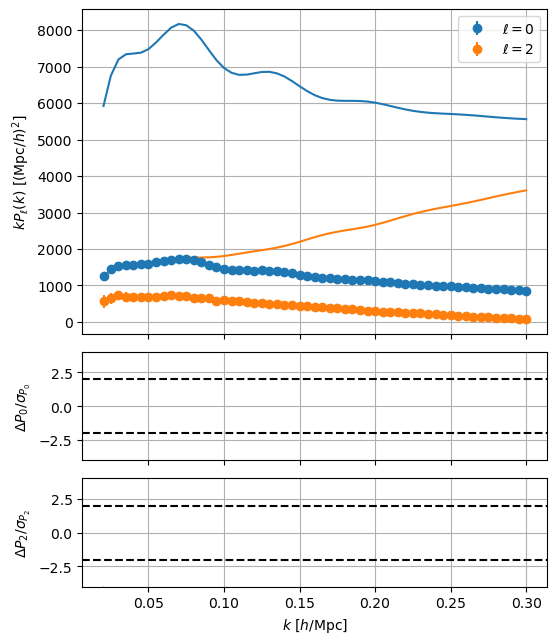

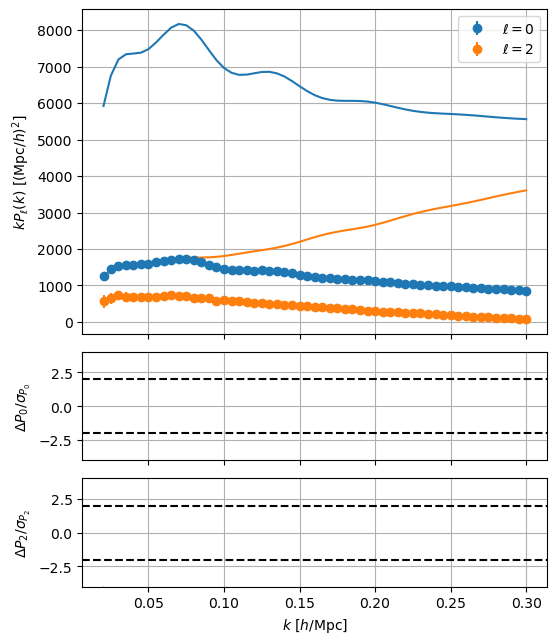

In [64]:
observables[tracer]['ps'].plot()

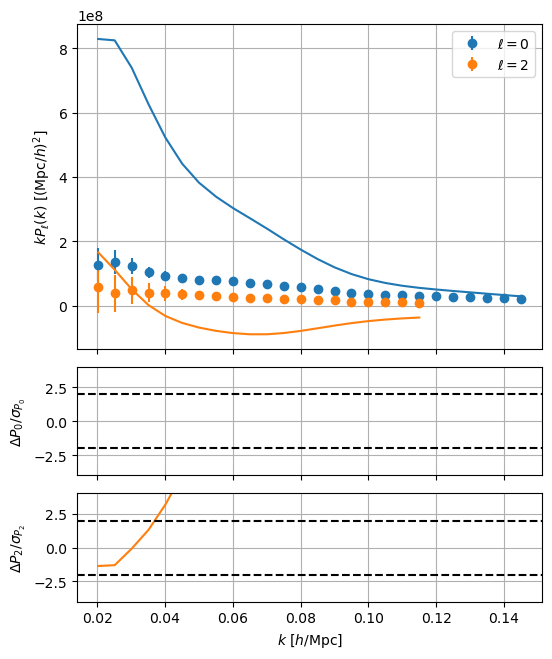

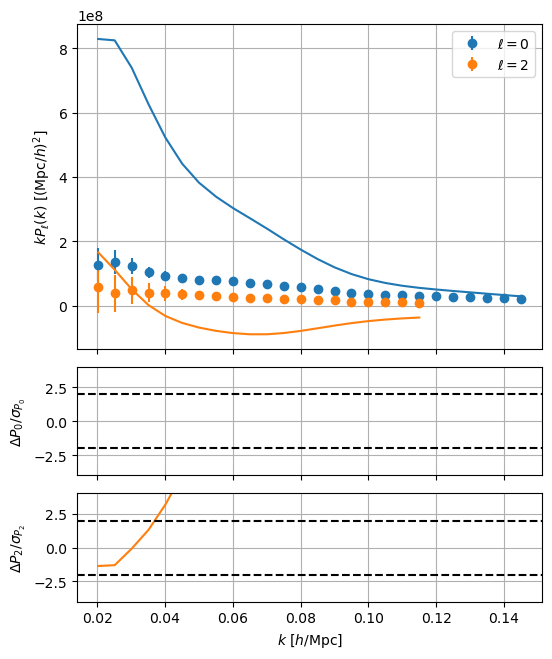

In [79]:
observables[tracer]['bs'].plot()

[000000.00] [0/1] 08-28 15:53  Chain                     INFO     Loading /global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2_fk_ps_0.301.npy.
chain: Chain(shape=(6720,), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'b1', 'b2', 'bs', 'X_FoG_p', 'fweight', 'logposterior', 'n_s', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'ct', 'b3', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'alpha0', 'alpha2', 'sn0', 'sn2']))
{'h': ParameterArray(h, None, 0.7250342698314056), 'omega_cdm': ParameterArray(omega_cdm, None, 0.17224316365323084), 'omega_b': ParameterArray(omega_b, None, 0.02390357972484353), 'logA': ParameterArray(logA, None, 2.000034276175796), 'b1': ParameterArray(b1, None, 3.5603547510373486), 'b2': ParameterArray(b2, None, 11.42589174077754), 'bs': ParameterArray(bs, None, -23.554142284381804), 'X_FoG_p': ParameterArray(X_FoG_p, None, 1.9620310834181274), 'n_s': ParameterArray(n_s, None, 0.9649), 'tau_reio': Pa

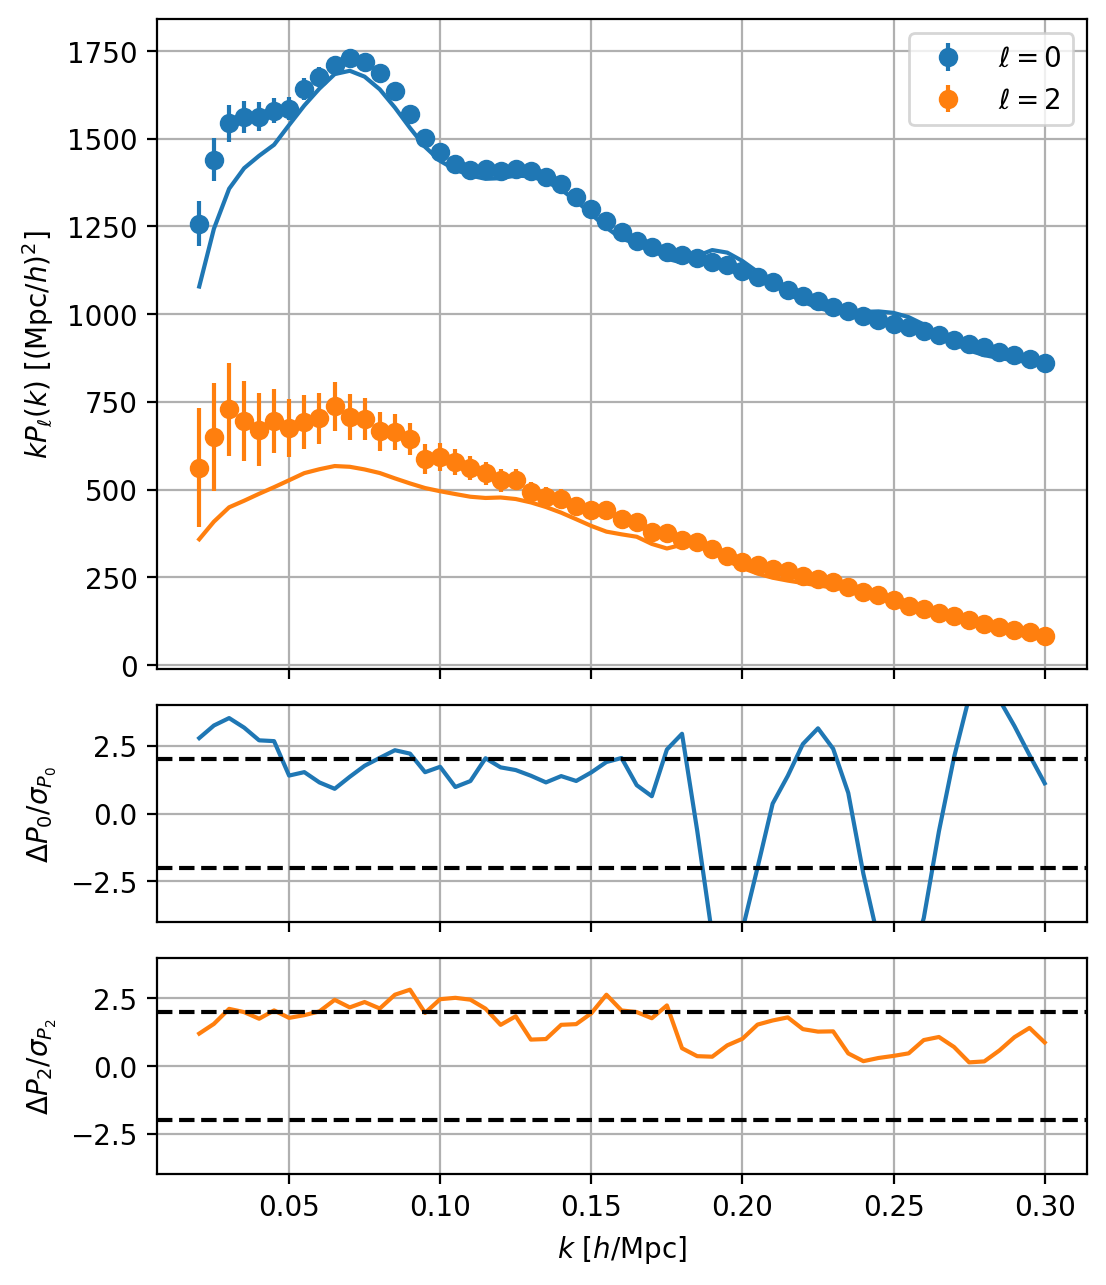

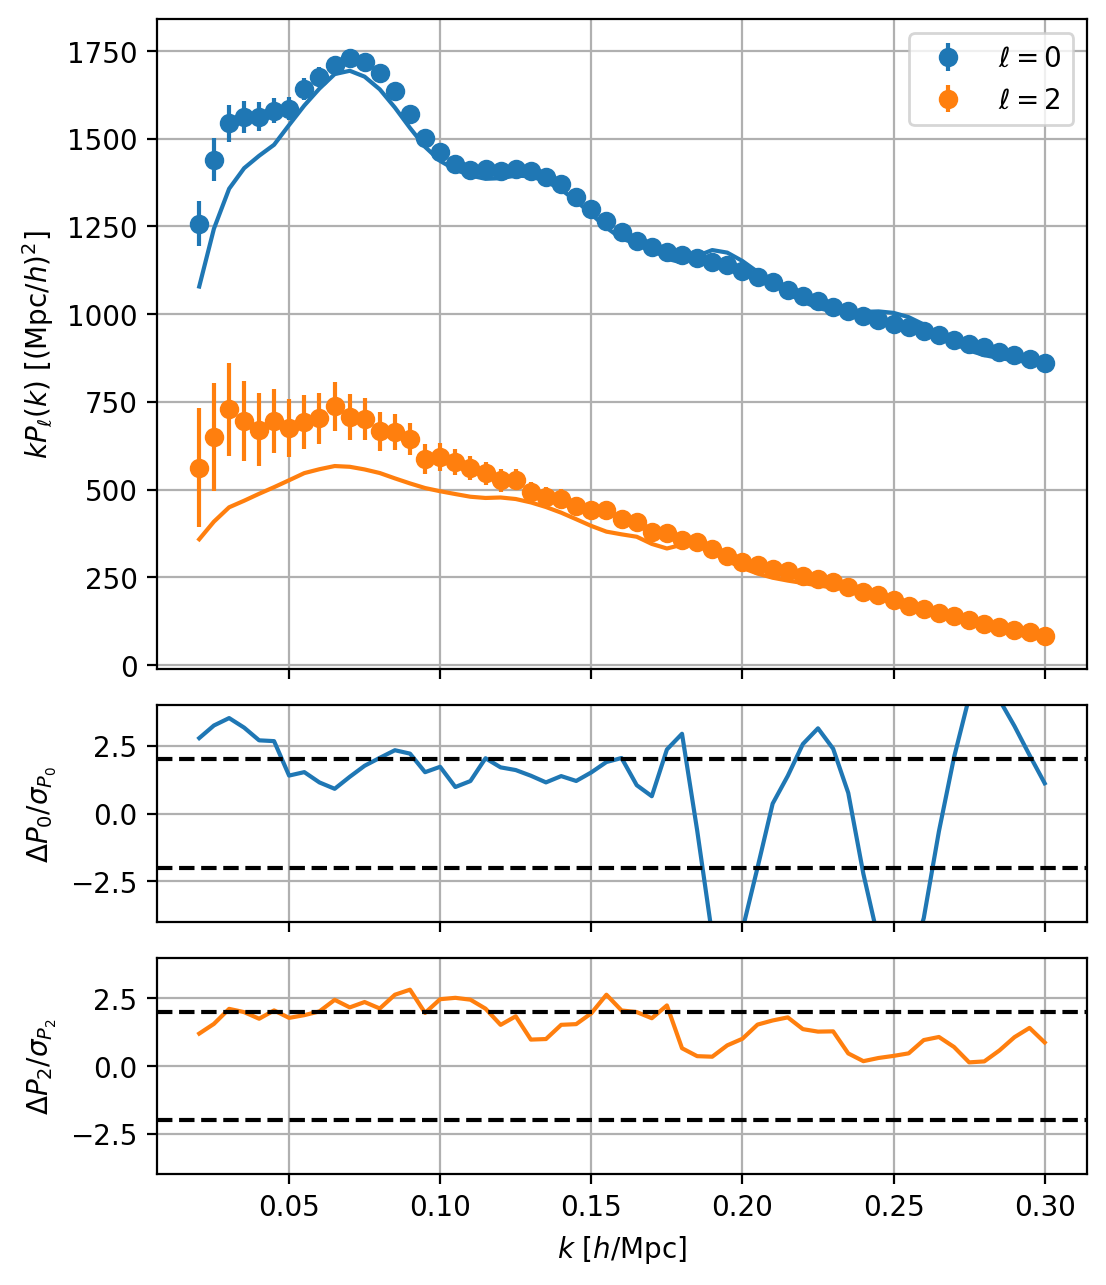

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from desilike.samples import Chain
from desilike import setup_logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
setup_logging()

#funtion to load numpy chains
def load_chain(fi, burnin=0.3):
    from desilike.samples import Chain
    # chains = [Chain.load(ff).remove_burnin(burnin) for ff in fi]
    chains = [Chain.load(fi).remove_burnin(burnin)]
    chain = chains[0].concatenate(chains)
    print(f'chain: {chain}')
    return chain
chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2_fk_ps_0.301.npy')
chain = load_chain(chain_path)
likelihood(**chain.choice(index='argmax', input=True))
print(chain.choice(index='argmax', input=True))
# observables['LRG2']['ps'].all_params['b2'].update(value=0.0)
observables['LRG2']['ps'].plot()


In [2]:
#model: LCDM or HS
model = 'LCDM'

#Put 'True' to resume chain. 'False' to start from 0 steps
restart_chain = False
#Biasing and EFT parametrization: 'physical' or 'default' (non-physical)
prior_basis = 'standard' #Prior to be used 

kr_max = 0.301
kr_b0_max = 0.15
kr_b2_max = 0.12


#width for EFT and SN paramss
width_EFT = 12.5
width_SN0 = 2.0
width_SN2 = 5.0

pt_model = "folps"  # Change this to "rept_velocileptors" or "pybird" as needed

sampler = 'cobaya'

set_emulator = True

GR_criteria = 0.01  # R - 1 < GR_criteria 


# Argument parser
#parser = argparse.ArgumentParser(description="Run MCMC analysis with different tracers")
#parser.add_argument("--tracers", nargs="+", required=True, help="List of tracers to use")
#args = parser.parse_args()


# List of tracers
# tracers = ['BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO']  # Add more tracers as needed
tracers = ['LRG2']
#tracers = args.tracers
all_tracers = {'BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO'}

if set(tracers) == all_tracers:
    tracers_str = "all"
else:
    tracers_str = "+".join(tracers)

chain_name = f'chains/MCMC-fs_abacus2gen_folpsv2_fk_eft_ps_0.201'
if not set_emulator:
    chain_name += '_noemu'
#print(chain_name)



from desilike import ParameterCollection

def make_params(prior_basis, width_EFT, width_SN0, width_SN2):
    params = ParameterCollection()

    if prior_basis == 'physical':
        # Shared params
        params['b1p'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2p'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bsp'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': 20}}

        # PS-only
        params['alpha0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha4p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['sn0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        params['sn2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}

        # BS-only → if physical, no c1,c2,Pshot,Bshot,X_FoG_b

    else:
        # Shared params
        params['b1'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bs'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['b3'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}

        # PS-only
        params['alpha0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha4'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['sn0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        params['sn2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}
        # params['alpha0'] = {'value':20,'fixed':True}
        # params['alpha2'] = {'value':-58.8,'fixed':True}
        # params['alpha4'] = {'value':0.0,'fixed':True}
        # params['sn0'] = {'value':-0.073,'fixed':True}
        # params['sn2'] = {'value':-6.38,'fixed':True}
        params['X_FoG_p'] = {'prior': {'dist':'uniform','limits': [0, 10]}}  # fixed in your snippet
        # params['X_FoG_p'] = {'fixed':True}  # fixed in your snippet

        # BS-only
        params['c1'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['c2'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['Pshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['Bshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['X_FoG_b'] = {'prior': {'dist':'uniform','limits': [0, 15]}}

    return params




#Define a cosmology to get sigma_8, Omega_m and fR0
cosmo = Cosmoprimo(engine='class')
cosmo.init.params['H0'] = dict(derived=True)
cosmo.init.params['Omega_m'] = dict(derived=True)
cosmo.init.params['sigma8_m'] = dict(derived=True) 
#cosmo.init.params['fR0'] = dict(derived=False, latex ='f_{R0}')
fiducial = DESI() #fiducial cosmology

#Update cosmo priors
for param in ['n_s', 'h','omega_cdm', 'omega_b', 'logA', 'tau_reio']:
    cosmo.params[param].update(fixed = False)
    if param == 'tau_reio':
        cosmo.params[param].update(fixed = True)
    if param == 'n_s':
            cosmo.params[param].update(fixed = True)
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.9649, 'scale': 0.042})
    if param == 'omega_b':
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02218, 'scale': 0.00055})
            cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02237, 'scale': 0.00037})  #From simulations
    if param == 'h':
            cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.5,0.9]})
    if param == 'omega_cdm':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.05, 0.2]})
    #if param == 'm_ncdm':
        #cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.0, 5]})
    if param == 'logA':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [2.0, 4.0]})


#Define tracer types and their corresponding redshifts
all_tracer_params = {
    'BGS': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4.npy'
    },
    'LRG1': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.4-0.6.npy'
    },
    'LRG2': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.6-0.8.npy'
    },
    'LRG3': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.8-1.1.npy'
    },
    'ELG': {
       'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_ELG_LOPnotqso_GCcomb_z1.1-1.6.npy'
    },
    'QSO': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_QSO_GCcomb_z0.8-2.1.npy'
    }
}  

all_tracer_redshifts = {
                        'BGS': 0.295,
                        'LRG1': 0.510,
                        'LRG2': 0.8,
                        'LRG3': 0.930,
                        'ELG': 1.317,
                        'QSO': 1.491
                        }

tracer_params = {index: all_tracer_params[tracer] for index, tracer in enumerate(tracers)}
tracer_redshifts = {tracer: all_tracer_redshifts[tracer] for tracer in tracers}


#Iterate over each tracer and create the corresponding theory object
# Theories container: dict of dicts
theories = {}

for tracer in tracers:
    z = tracer_redshifts[tracer]
    template = DirectPowerSpectrumTemplate(fiducial=fiducial, cosmo=cosmo, z=z)

    # PS theory selection
    if pt_model == "rept_velocileptors":
        ps_theory = REPTVelocileptorsTracerPowerSpectrumMultipoles(template=template,
                                                                   prior_basis=prior_basis)
    else:
        # ps_theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template,
        #                                                  prior_basis=prior_basis)
        ps_theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template,
                                                         prior_basis=prior_basis)

    # BS theory always FOLPSv2 in your snippet
    bs_theory = FOLPSv2TracerBispectrumMultipoles(template=template,
                                                  prior_basis=prior_basis)

    # Store
    theories[tracer] = {"ps": ps_theory, "bs": bs_theory}

    # --- Update parameters ---
    params = make_params(prior_basis, width_EFT, width_SN0, width_SN2)
    for name, p in params.items():
        for comp in ["ps", "bs"]:
            if name in theories[tracer][comp].params:
                theories[tracer][comp].params[name].update(p)


    print("X_FoG_p=",params['X_FoG_p'].value)
    print("b3=",params['b3'].value)


        
    

    for param in ps_theory.all_params:
        print(param,':',ps_theory.all_params[param].prior)
    for param in bs_theory.all_params:
        print(param,':',bs_theory.all_params[param].prior)

#Define data vector and covariance using mike data tools

def load_data_vector_and_covariance():
    k_min=0.02
    k_max=0.301
    k_max_b0 = 0.15
    k_max_b2 = 0.12

    isP0, isP2, isP4 =True, True, False
    isB000, isB202 = True, True

    Vol=1

    tracer='LRG'
    z_str='z0.800'
    z_evaluation=0.8

    path_fits='chains/'

    now = datetime.now()
    tiempo=now.strftime("%m-%d-%Y-%H%M")

    name=f"c_FolpsD__{tracer}_z{z_evaluation:.3f}_Pkmax-{k_max:.3f}_B000kmax-{k_max_b0:.3f}_B202kmax-{k_max_b2:.3f}_bsfree"


    chains_filename = path_fits+name+".h5"
    copy_filename = path_fits+name+".py"
    print(chains_filename)
        

    # +
    k_data_2nd,pkl0_2nd_all,pkl2_2nd_all,a,B000_2nd_all,B202_2nd_all = ExtractDataAbacusSummit(tracer,z_str,
                                                                                            subtract_shot=True)

    Pk_0_2nd = np.mean(pkl0_2nd_all,axis = 0)
    Pk_2_2nd = np.mean(pkl2_2nd_all,axis = 0)
    B000_2nd = np.mean(B000_2nd_all,axis = 0)
    B202_2nd = np.mean(B202_2nd_all,axis = 0)

    # Read covariance

    k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks = ExtractDataEZmock(tracer,z_str)
    k_cov_all, mean_ezmocks_all, cov_array_all = covariance(k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks, Nscaling = Vol)



    pole_selection=[isP0, isP2, isP4,isB000, isB202]
    print(pole_selection)

    kmin_pk=0.02; kmax_pk=k_max
    kmin_bk=0.02; 
    ranges=[[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_bk,k_max_b0],[kmin_bk,k_max_b2]]

    mask=pole_k_selection(k_cov_all,pole_selection,ranges)
    #print(mask.shape)
    #print(mask)
    k_cov=k_cov_all[mask]

    #k_cov.shape
    k_points_pk = np.where((kmin_pk < k_data_2nd) & (k_data_2nd < kmax_pk)  & isP0)
    k_points_b0 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b0) & isB000)
    k_points_b2 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b2) & isB202)

    data = np.concatenate((Pk_0_2nd[k_points_pk],Pk_2_2nd[k_points_pk],
                        B000_2nd[k_points_b0],B202_2nd[k_points_b2]))
    kr_pk=k_data_2nd[k_points_pk]
    kr_b0=k_data_2nd[k_points_b0]
    kr_b2=k_data_2nd[k_points_b2]

    numberofpk0points=len(Pk_0_2nd[k_points_pk])
    numberofbk0points=len(B000_2nd[k_points_b0])
    numberofbk2points=len(B202_2nd[k_points_b2])

    cov_array=cov_array_all[np.ix_(mask, mask)]
    totsim = 2000 #number of sims
    n_data = len(data)
    Hartlap = (totsim - 1.) / (totsim - n_data - 2.)
    Hartlap
    cov_arr = cov_array * Hartlap
    # cov_inv_arr = np.linalg.inv(cov_arr)
    
    N_ck=25  #kmaxThy = 0.01 * N_ck + 0.0025 + 0.0005
    N_ck = max(int(k_max*100)+2,25)
    print(N_ck)
    
    k_thy_2nd_ext = np.linspace(0.0, 0.01*N_ck, 2 * N_ck * 5,endpoint=False) + 0.0025+0.0005 #+ 0.0025(move to first data bin) + 0.0005(move to center of bin)
    
    ko_2nd_ext=k_data_2nd[0: 2 * N_ck]
    
    m_bin_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    m_bin_k_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    
    for i,ki in enumerate(ko_2nd_ext):
        norm_2nd_ext = (1./3.)* ( (k_thy_2nd_ext[5*i + (5-1)])**3 - (k_thy_2nd_ext[5*i])**3 )
        for j in range(5):
            ff=((5-1)/5)
            m_bin_2nd_ext[i,5*i + j] = (k_thy_2nd_ext[5*i + j]**2)*0.001 / norm_2nd_ext * ff
            m_bin_k_2nd_ext[i,5*i + j] = k_thy_2nd_ext[5*i + j]
    
    
    k_thy=k_thy_2nd_ext
    m_bin=m_bin_2nd_ext

    kb_all=np.linspace(0.5*k_thy_2nd_ext[0], 0.28, 60)
    k_ev_bk=np.vstack([kb_all,kb_all]).T
    
    
    # np.save("./desilike_mcmc/kr_b0.npy",kr_b0)
    # np.save("./desilike_mcmc/data_b0.npy",data)
    # np.save("./desilike_mcmc/cov_b0.npy",cov_array)
    return data, cov_array, kr_pk,kr_b0, kr_b2, k_thy, kb_all,m_bin,k_points_pk,k_points_b0,k_points_b2

def load_data_vector_and_covariance_files():
    kr_pk = np.load("./desilike_mcmc/kr_pk.npy")
    data = np.load("./desilike_mcmc/data.npy")
    cov_arr = np.load("./desilike_mcmc/cov.npy")
    return data, cov_arr, kr_pk





#Define a function to create an observable
def create_observable(tracer, comp):
    global cov_arr
    data, cov_arr, kr_pk, kr_b0, kr_b2, k_thy, kb_all, m_bin, k_points_pk, k_points_b0, k_points_b2 = load_data_vector_and_covariance()
    print(kr_pk.shape)
    # cov_arr *= 0.2

    if comp == "ps":
        from scipy.linalg import block_diag

        # build window matrix for ell=0 and ell=2 separately
        wmatrix_pk = m_bin[np.asarray(k_points_pk).ravel(), :]   # (57, 320)
        
        # each ell gets its own mapping (57, 320)
        wmatrix_ell0 = wmatrix_pk
        wmatrix_ell2 = wmatrix_pk
        
        # block diagonal → (114, 640)
        wmatrix = block_diag(wmatrix_ell0, wmatrix_ell2)
        return TracerPowerSpectrumMultipolesObservable(
            data=data[:2*len(kr_pk)],
            covariance=cov_arr[:2*len(kr_pk), :2*len(kr_pk)],
            theory=theories[tracer]["ps"],
             kin = k_thy,
             ells=[0, 2], k=kr_pk, wmatrix=wmatrix
        )
      
    elif comp == "bs":
        start = len(data) - (len(kr_b0) + len(kr_b2))
    
        # Select rows of m_bin corresponding to b0 and b2 observed k-points
        wmatrix_b0 = m_bin[np.asarray(k_points_b0).ravel(), :]  # shape (len(kr_b0), n_theory)
        wmatrix_b2 = m_bin[np.asarray(k_points_b2).ravel(), :]  # shape (len(kr_b2), n_theory)
    
        # Block diagonalize to keep ell=0, ell=2 separate
        from scipy.linalg import block_diag
        wmatrix = block_diag(wmatrix_b0, wmatrix_b2)  # shape (len(kr_b0)+len(kr_b2), 2*n_theory)
    
        return TracerPowerSpectrumMultipolesObservable(
            data=data[start:],
            covariance=cov_arr[start:, start:],
            theory=theories[tracer]["bs"],
            kin=k_thy,   # provide theory grid for both multipoles
            ells=[0, 2],
            k=[kr_b0,kr_b2],  # observed bin centers
            wmatrix=wmatrix
        )

#Create observables for each tracer
observables = {}
for tracer in tracers:
    observables[tracer] = {
        "ps": create_observable(tracer, "ps"),
        "bs": create_observable(tracer, "bs")
    }



if set_emulator:
    for tracer in tracers:
        for comp in ["ps"]:  # handle PS and BS separately
            obs = observables[tracer][comp]

            emulator_filename = f'Emulator_test_sims_{comp}/{comp}_emu_{tracers_str}_{tracer}_{kr_max}_folpsv2_fk.npy'
            os.makedirs(os.path.dirname(emulator_filename), exist_ok=True)

            if os.path.exists(emulator_filename):
                print(f"{comp.upper()} emulator for tracer {tracer} already exists, loading it now")
                emulator = EmulatedCalculator.load(emulator_filename)
                theories[tracer][comp].init.update(pt=emulator)
                # obs.theory.init.update(pt=emulator)

            else:
                print(f"Fitting {comp.upper()} emulator for tracer {tracer}")
                # Start from the underlying PT theory
                theory = obs.wmatrix.theory

                emulator = Emulator(
                    theory.pt,
                    engine=TaylorEmulatorEngine(method='finite', order=4)
                )
                emulator.set_samples()
                emulator.fit()
                emulated_pt = emulator.to_calculator()
                emulated_pt.save(emulator_filename)
                theories[tracer][comp].init.update(pt=emulated_pt)
                # obs.theory.init.update(pt=emulated_pt)

            

print('All theories have been emulated successfully' if set_emulator else 'EMULATOR NOT ACTIVATED, proceeding without emulation')



#Analytic marginalization over eft and nuisance parameters
for i in (tracers): 
    if prior_basis == 'physical':
        params_list = ['alpha0p', 'alpha2p', 'alpha4p', 'sn0p', 'sn2p']
    else:
         params_list = ['alpha0', 'alpha2', 'alpha4', 'sn0', 'sn2']

    for param in params_list:    
        theories[i]['ps'].params[param].update(derived = '.marg')
    theories[i]['ps'].params['b3'].update(derived = '32/315*({b1}-1)')

        
#Rename the eft and nuisance parameters to get a parameter for each tracer (i.e. QSO_alpha0, QSO_alpha2, BGS_alpha0,...)        
# for i in range(len(theories)):    
#     for param in theories[i].init.params:
#         # Update latex just to have better labels
#         param.update(namespace='{}'.format(tracers[i])) 
        

#Create a likelihood per theory object
setup_logging()
Likelihoods = []
for tracer in tracers:
        Likelihoods.append(ObservablesGaussianLikelihood(
        observables[tracer]['ps']
        ))
   # observables=[observables[tracer]['ps'],observables[tracer]['bs']],
   #          covariance=cov_arr
likelihood = SumLikelihood(Likelihoods)

likelihood()

X_FoG_p= 5.0
b3= 0.0
✅ Using NumPy with CPU.
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20240118-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
omega_b : norm({'loc': 0.02237, 'scale': 0.00037})
logA : uniform[2.0, 4.0]({})
n_s : uniform[0.8, 1.2]({})
tau_reio : uniform[0.01, 0.8]({})
m_ncdm : uniform[0.0, 5.0]({})
N_eff : uniform[0.01, 10.0]({})
w0_fld : uniform[-3.0, 1.0]({})
wa_fld : uniform[-3.0, 2.0]({})
Omega_k : uniform[-0.3, 0.3]({})
H0 : uniform({})
Omega_m : uniform({})
sigma8_m : uniform({})
b1 : uniform[1e-05, 10]({})
b2 : uniform[-50, 50]({})
bs : uniform[-50, 50]({})
b3 : uniform[-50, 50]({})
alpha0 : norm({'loc': 0.0, 'scale': 12.5})
alpha2 : norm({'loc': 0.0, 'scale': 12.5})
alpha4 : norm({'loc': 0.0, 'scale': 12.5})
ct : uniform({})
sn0 : norm({'loc': 0.0, 'scale': 2.0})
sn2 : norm({'loc': 0.0, 'scale': 5.0})
X_FoG_p : uniform[0, 10]({})
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
o

/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter loglikelihood of <desilike.likelihoods.base.SumLikelihood object at 0x7fe62c1a0850> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7fe62c1a0040>.
  if self.mpicomm.rank == 0: warnings.warn(msg)
/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter logprior of <desilike.likelihoods.base.SumLikelihood object at 0x7fe62c1a0850> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7fe62c1a0040>.
  if self.mpicomm.rank == 0: warnings.warn(msg)


Array(-536035.3631553, dtype=float64)

In [1]:
import sys
import os
sys.path.insert(0, "/global/u1/p/prakharb/desilike")
#sys.path.insert(0, "/global/u1/p/prakharb/desilike")
#sys.path.insert(0, "/global/u1/p/prakharb/cosmoprimo")
import desilike, inspect
print(inspect.getfile(desilike))


import numpy as np
import matplotlib.pyplot as plt
from desilike.theories.galaxy_clustering import LPTVelocileptorsTracerPowerSpectrumMultipoles, REPTVelocileptorsTracerPowerSpectrumMultipoles,  DirectPowerSpectrumTemplate, ShapeFitPowerSpectrumTemplate
from desilike.theories.galaxy_clustering.full_shape import FOLPSv2TracerPowerSpectrumMultipoles, FOLPSAXTracerPowerSpectrumMultipoles, FOLPSv2TracerBispectrumMultipoles
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable 
from desilike.observables import ObservableCovariance
from desilike.emulators import EmulatedCalculator, Emulator, TaylorEmulatorEngine
from desilike.likelihoods import ObservablesGaussianLikelihood, SumLikelihood
from desilike.theories import Cosmoprimo
from cosmoprimo.fiducial import DESI
from desilike import setup_logging
from desilike.parameter import Parameter, ParameterPrior
import argparse
import sys, os, shutil
import time
import emcee
import numpy as np
from schwimmbad import MPIPool
from datetime import datetime
from desilike_mcmc.mike_data_tools import *







# In[ ]:


######### Settings #########

#model: LCDM or HS
model = 'LCDM'

#Put 'True' to resume chain. 'False' to start from 0 steps
restart_chain = False
#Biasing and EFT parametrization: 'physical' or 'default' (non-physical)
prior_basis = 'standard' #Prior to be used 

kr_max = 0.201
kr_b0_max = 0.15
kr_b2_max = 0.12


#width for EFT and SN paramss
width_EFT = 12.5
width_SN0 = 2.0
width_SN2 = 5.0

pt_model = "folps"  # Change this to "rept_velocileptors" or "pybird" as needed

sampler = 'cobaya'

set_emulator = True

GR_criteria = 0.01  # R - 1 < GR_criteria 


# Argument parser
#parser = argparse.ArgumentParser(description="Run MCMC analysis with different tracers")
#parser.add_argument("--tracers", nargs="+", required=True, help="List of tracers to use")
#args = parser.parse_args()


# List of tracers
# tracers = ['BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO']  # Add more tracers as needed
tracers = ['LRG2']
#tracers = args.tracers
all_tracers = {'BGS', 'LRG1', 'LRG2', 'LRG3', 'ELG', 'QSO'}

if set(tracers) == all_tracers:
    tracers_str = "all"
else:
    tracers_str = "+".join(tracers)

chain_name = f'chains/MCMC-fs_abacus2gen_folpsv2_fk_ps_0.201_Afull_false'
if not set_emulator:
    chain_name += '_noemu'
#print(chain_name)



from desilike import ParameterCollection

def make_params(prior_basis, width_EFT, width_SN0, width_SN2):
    params = ParameterCollection()

    if prior_basis == 'physical':
        # Shared params
        params['b1p'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2p'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bsp'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': 20}}

        # PS-only
        params['alpha0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha4p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['sn0p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        params['sn2p'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}

        # BS-only → if physical, no c1,c2,Pshot,Bshot,X_FoG_b

    else:
        # Shared params
        params['b1'] = {'prior': {'dist':'uniform','limits': [1e-5, 10]}}
        params['b2'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['bs'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        # params['b3'] = {'prior': {'dist':'uniform','limits': [-50, 50]}}
        params['b3'] = {'fixed':True}

        # PS-only
        params['alpha0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['alpha4'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_EFT}}
        params['sn0'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN0}}
        params['sn2'] = {'prior': {'dist': 'norm', 'loc': 0, 'scale': width_SN2}}
        # params['alpha0'] = {'value':20,'fixed':True}
        # params['alpha2'] = {'value':-58.8,'fixed':True}
        # params['alpha4'] = {'value':0.0,'fixed':True}
        # params['sn0'] = {'value':-0.073,'fixed':True}
        # params['sn2'] = {'value':-6.38,'fixed':True}
        # params['X_FoG_p'] = {'prior': {'dist':'uniform','limits': [0, 10]}} 
        params['X_FoG_p'] = {'fixed':True}  # fixed in your snippet

        # BS-only
        params['c1'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['c2'] = {'prior': {'dist':'uniform','limits': [-2000, 2000]}}
        params['Pshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['Bshot'] = {'prior': {'dist':'uniform','limits': [-50000, 50000]}}
        params['X_FoG_b'] = {'prior': {'dist':'uniform','limits': [0, 15]}}

    return params




#Define a cosmology to get sigma_8, Omega_m and fR0
cosmo = Cosmoprimo(engine='class')
cosmo.init.params['H0'] = dict(derived=True)
cosmo.init.params['Omega_m'] = dict(derived=True)
cosmo.init.params['sigma8_m'] = dict(derived=True) 
#cosmo.init.params['fR0'] = dict(derived=False, latex ='f_{R0}')
fiducial = DESI() #fiducial cosmology

#Update cosmo priors
for param in ['n_s', 'h','omega_cdm', 'omega_b', 'logA', 'tau_reio']:
    cosmo.params[param].update(fixed = False)
    if param == 'tau_reio':
        cosmo.params[param].update(fixed = True)
    if param == 'n_s':
            cosmo.params[param].update(fixed = True)
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.9649, 'scale': 0.042})
    if param == 'omega_b':
            # cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02218, 'scale': 0.00055})
            cosmo.params[param].update(prior={'dist': 'norm', 'loc': 0.02237, 'scale': 0.00037})  #From simulations
    if param == 'h':
            cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.5,0.9]})
    if param == 'omega_cdm':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.05, 0.2]})
    #if param == 'm_ncdm':
        #cosmo.params[param].update(prior = {'dist':'uniform','limits': [0.0, 5]})
    if param == 'logA':
        cosmo.params[param].update(prior = {'dist':'uniform','limits': [2.0, 4.0]})


#Define tracer types and their corresponding redshifts
all_tracer_params = {
    'BGS': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_BGS_BRIGHT-21.5_GCcomb_z0.1-0.4.npy'
    },
    'LRG1': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.4-0.6.npy'
    },
    'LRG2': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.6-0.8.npy'
    },
    'LRG3': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_LRG_GCcomb_z0.8-1.1.npy'
    },
    'ELG': {
       'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_ELG_LOPnotqso_GCcomb_z1.1-1.6.npy'
    },
    'QSO': {
        'data_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/forfit_2pt/forfit_power_syst-rotation-hod-photo_klim_0-0.02-0.20_2-0.02-0.20_QSO_GCcomb_z0.8-2.1.npy'
    }
}  

all_tracer_redshifts = {
                        'BGS': 0.295,
                        'LRG1': 0.510,
                        'LRG2': 0.8,
                        'LRG3': 0.930,
                        'ELG': 1.317,
                        'QSO': 1.491
                        }

tracer_params = {index: all_tracer_params[tracer] for index, tracer in enumerate(tracers)}
tracer_redshifts = {tracer: all_tracer_redshifts[tracer] for tracer in tracers}


#Iterate over each tracer and create the corresponding theory object
# Theories container: dict of dicts
theories = {}

for tracer in tracers:
    z = tracer_redshifts[tracer]
    template = DirectPowerSpectrumTemplate(fiducial=fiducial, cosmo=cosmo, z=z)

    # PS theory selection
    if pt_model == "rept_velocileptors":
        ps_theory = REPTVelocileptorsTracerPowerSpectrumMultipoles(template=template,
                                                                   prior_basis=prior_basis)
    else:
        # ps_theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template,
        #                                                  prior_basis=prior_basis)
        ps_theory = FOLPSv2TracerPowerSpectrumMultipoles(template=template,
                                                         prior_basis=prior_basis, A_full=False)

    # BS theory always FOLPSv2 in your snippet
    bs_theory = FOLPSv2TracerBispectrumMultipoles(template=template,
                                                  prior_basis=prior_basis)

    # Store
    theories[tracer] = {"ps": ps_theory, "bs": bs_theory}

    # --- Update parameters ---
    params = make_params(prior_basis, width_EFT, width_SN0, width_SN2)
    for name, p in params.items():
        for comp in ["ps", "bs"]:
            if name in theories[tracer][comp].params:
                theories[tracer][comp].params[name].update(p)


    print("X_FoG_p=",params['X_FoG_p'].value)
    print("b3=",params['b3'].value)


        
    

    for param in ps_theory.all_params:
        print(param,':',ps_theory.all_params[param].prior)
    for param in bs_theory.all_params:
        print(param,':',bs_theory.all_params[param].prior)

#Define data vector and covariance using mike data tools

def load_data_vector_and_covariance():
    k_min=0.02
    k_max=0.201
    k_max_b0 = 0.15
    k_max_b2 = 0.12

    isP0, isP2, isP4 =True, True, False
    isB000, isB202 = True, True

    Vol=1

    tracer='LRG'
    z_str='z0.800'
    z_evaluation=0.8

    path_fits='chains/'

    now = datetime.now()
    tiempo=now.strftime("%m-%d-%Y-%H%M")

    name=f"c_FolpsD__{tracer}_z{z_evaluation:.3f}_Pkmax-{k_max:.3f}_B000kmax-{k_max_b0:.3f}_B202kmax-{k_max_b2:.3f}_bsfree"


    chains_filename = path_fits+name+".h5"
    copy_filename = path_fits+name+".py"
    print(chains_filename)
        

    # +
    k_data_2nd,pkl0_2nd_all,pkl2_2nd_all,a,B000_2nd_all,B202_2nd_all = ExtractDataAbacusSummit(tracer,z_str,
                                                                                            subtract_shot=True)

    Pk_0_2nd = np.mean(pkl0_2nd_all,axis = 0)
    Pk_2_2nd = np.mean(pkl2_2nd_all,axis = 0)
    B000_2nd = np.mean(B000_2nd_all,axis = 0)
    B202_2nd = np.mean(B202_2nd_all,axis = 0)

    # Read covariance

    k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks = ExtractDataEZmock(tracer,z_str)
    k_cov_all, mean_ezmocks_all, cov_array_all = covariance(k_eff_all,pkl0ezmocks,pkl2ezmocks,pkl4ezmocks,B000ezmocks,B202ezmocks, Nscaling = Vol)



    pole_selection=[isP0, isP2, isP4,isB000, isB202]
    print(pole_selection)

    kmin_pk=0.02; kmax_pk=k_max
    kmin_bk=0.02; 
    ranges=[[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_pk,kmax_pk],[kmin_bk,k_max_b0],[kmin_bk,k_max_b2]]

    mask=pole_k_selection(k_cov_all,pole_selection,ranges)
    #print(mask.shape)
    #print(mask)
    k_cov=k_cov_all[mask]

    #k_cov.shape
    k_points_pk = np.where((kmin_pk < k_data_2nd) & (k_data_2nd < kmax_pk)  & isP0)
    k_points_b0 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b0) & isB000)
    k_points_b2 = np.where((kmin_bk < k_data_2nd) & (k_data_2nd < k_max_b2) & isB202)

    data = np.concatenate((Pk_0_2nd[k_points_pk],Pk_2_2nd[k_points_pk],
                        B000_2nd[k_points_b0],B202_2nd[k_points_b2]))
    kr_pk=k_data_2nd[k_points_pk]
    kr_b0=k_data_2nd[k_points_b0]
    kr_b2=k_data_2nd[k_points_b2]

    numberofpk0points=len(Pk_0_2nd[k_points_pk])
    numberofbk0points=len(B000_2nd[k_points_b0])
    numberofbk2points=len(B202_2nd[k_points_b2])

    cov_array=cov_array_all[np.ix_(mask, mask)]
    totsim = 2000 #number of sims
    n_data = len(data)
    Hartlap = (totsim - 1.) / (totsim - n_data - 2.)
    Hartlap
    cov_arr = cov_array * Hartlap
    # cov_inv_arr = np.linalg.inv(cov_arr)
    
    N_ck=25  #kmaxThy = 0.01 * N_ck + 0.0025 + 0.0005
    N_ck = max(int(k_max*100)+2,25)
    print(N_ck)
    
    k_thy_2nd_ext = np.linspace(0.0, 0.01*N_ck, 2 * N_ck * 5,endpoint=False) + 0.0025+0.0005 #+ 0.0025(move to first data bin) + 0.0005(move to center of bin)
    
    ko_2nd_ext=k_data_2nd[0: 2 * N_ck]
    
    m_bin_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    m_bin_k_2nd_ext = np.zeros((len(ko_2nd_ext),len(k_thy_2nd_ext)))
    
    for i,ki in enumerate(ko_2nd_ext):
        norm_2nd_ext = (1./3.)* ( (k_thy_2nd_ext[5*i + (5-1)])**3 - (k_thy_2nd_ext[5*i])**3 )
        for j in range(5):
            ff=((5-1)/5)
            m_bin_2nd_ext[i,5*i + j] = (k_thy_2nd_ext[5*i + j]**2)*0.001 / norm_2nd_ext * ff
            m_bin_k_2nd_ext[i,5*i + j] = k_thy_2nd_ext[5*i + j]
    
    
    k_thy=k_thy_2nd_ext
    m_bin=m_bin_2nd_ext

    kb_all=np.linspace(0.5*k_thy_2nd_ext[0], 0.28, 60)
    k_ev_bk=np.vstack([kb_all,kb_all]).T
    
    
    # np.save("./desilike_mcmc/kr_b0.npy",kr_b0)
    # np.save("./desilike_mcmc/data_b0.npy",data)
    # np.save("./desilike_mcmc/cov_b0.npy",cov_array)
    return data, cov_array, kr_pk,kr_b0, kr_b2, k_thy, kb_all,m_bin,k_points_pk,k_points_b0,k_points_b2

def load_data_vector_and_covariance_files():
    kr_pk = np.load("./desilike_mcmc/kr_pk.npy")
    data = np.load("./desilike_mcmc/data.npy")
    cov_arr = np.load("./desilike_mcmc/cov.npy")
    return data, cov_arr, kr_pk





#Define a function to create an observable
def create_observable(tracer, comp):
    global cov_arr
    data, cov_arr, kr_pk, kr_b0, kr_b2, k_thy, kb_all, m_bin, k_points_pk, k_points_b0, k_points_b2 = load_data_vector_and_covariance()
    print(kr_pk.shape)
    # cov_arr *= 0.2

    if comp == "ps":
        from scipy.linalg import block_diag

        # build window matrix for ell=0 and ell=2 separately
        wmatrix_pk = m_bin[np.asarray(k_points_pk).ravel(), :]   # (57, 320)
        
        # each ell gets its own mapping (57, 320)
        wmatrix_ell0 = wmatrix_pk
        wmatrix_ell2 = wmatrix_pk
        
        # block diagonal → (114, 640)
        wmatrix = block_diag(wmatrix_ell0, wmatrix_ell2)
        return TracerPowerSpectrumMultipolesObservable(
            data=data[:2*len(kr_pk)],
            covariance=cov_arr[:2*len(kr_pk), :2*len(kr_pk)],
            theory=theories[tracer]["ps"],
             kin = k_thy,
             ells=[0, 2], k=kr_pk, wmatrix=wmatrix
        )
      
    elif comp == "bs":
        start = len(data) - (len(kr_b0) + len(kr_b2))
    
        # Select rows of m_bin corresponding to b0 and b2 observed k-points
        wmatrix_b0 = m_bin[np.asarray(k_points_b0).ravel(), :]  # shape (len(kr_b0), n_theory)
        wmatrix_b2 = m_bin[np.asarray(k_points_b2).ravel(), :]  # shape (len(kr_b2), n_theory)
    
        # Block diagonalize to keep ell=0, ell=2 separate
        from scipy.linalg import block_diag
        wmatrix = block_diag(wmatrix_b0, wmatrix_b2)  # shape (len(kr_b0)+len(kr_b2), 2*n_theory)
    
        return TracerPowerSpectrumMultipolesObservable(
            data=data[start:],
            covariance=cov_arr[start:, start:],
            theory=theories[tracer]["bs"],
            kin=k_thy,   # provide theory grid for both multipoles
            ells=[0, 2],
            k=[kr_b0,kr_b2],  # observed bin centers
            wmatrix=wmatrix
        )

#Create observables for each tracer
observables = {}
for tracer in tracers:
    observables[tracer] = {
        "ps": create_observable(tracer, "ps"),
    }



if set_emulator:
    for tracer in tracers:
        for comp in ["ps"]:  # handle PS and BS separately
            obs = observables[tracer][comp]

            emulator_filename = f'Emulator_test_sims_{comp}/{comp}_emu_{tracers_str}_{tracer}_{kr_max}_folpsv2_fk_no_Afull.npy'
            os.makedirs(os.path.dirname(emulator_filename), exist_ok=True)

            if os.path.exists(emulator_filename):
                print(f"{comp.upper()} emulator for tracer {tracer} already exists, loading it now")
                emulator = EmulatedCalculator.load(emulator_filename)
                theories[tracer][comp].init.update(pt=emulator)
                # obs.theory.init.update(pt=emulator)

            else:
                print(f"Fitting {comp.upper()} emulator for tracer {tracer}")
                # Start from the underlying PT theory
                theory = obs.wmatrix.theory

                emulator = Emulator(
                    theory.pt,
                    engine=TaylorEmulatorEngine(method='finite', order=4)
                )
                emulator.set_samples()
                emulator.fit()
                emulated_pt = emulator.to_calculator()
                emulated_pt.save(emulator_filename)
                theories[tracer][comp].init.update(pt=emulated_pt)
                # obs.theory.init.update(pt=emulated_pt)

            

print('All theories have been emulated successfully' if set_emulator else 'EMULATOR NOT ACTIVATED, proceeding without emulation')



#Analytic marginalization over eft and nuisance parameters
for i in (tracers): 
    if prior_basis == 'physical':
        params_list = ['alpha0p', 'alpha2p', 'alpha4p', 'sn0p', 'sn2p']
    else:
         params_list = ['alpha0', 'alpha2', 'alpha4', 'sn0', 'sn2']

    for param in params_list:    
        theories[i]['ps'].params[param].update(derived = '.marg')
    # theories[i]['ps'].params['b3'].update(derived = '32/315*({b1}-1)')
    # print("b1=",theories[i]['ps'].params['b1'].value,"b3=",theories[i]['ps'].params['b3'].value)
        
#Rename the eft and nuisance parameters to get a parameter for each tracer (i.e. QSO_alpha0, QSO_alpha2, BGS_alpha0,...)        
# for i in range(len(theories)):    
#     for param in theories[i].init.params:
#         # Update latex just to have better labels
#         param.update(namespace='{}'.format(tracers[i])) 
        

#Create a likelihood per theory object
setup_logging()
Likelihoods = []
for tracer in tracers:
        Likelihoods.append(ObservablesGaussianLikelihood(
        observables[tracer]['ps']
        ))
   # observables=[observables[tracer]['ps'],observables[tracer]['bs']],
   #          covariance=cov_arr
likelihood = SumLikelihood(Likelihoods)

print(likelihood())

/global/u1/p/prakharb/desilike/desilike/__init__.py
X_FoG_p= 0.0
b3= 0.0
✅ Using NumPy with CPU.
Loading matrices from matrices_nfftlog128_Afull_False_remove-DeltaP_False.npy


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20240118-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Loading matrices from matrices_nfftlog128_Afull_False_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
omega_b : norm({'loc': 0.02237, 'scale': 0.00037})
logA : uniform[2.0, 4.0]({})
n_s : uniform[0.8, 1.2]({})
tau_reio : uniform[0.01, 0.8]({})
m_ncdm : uniform[0.0, 5.0]({})
N_eff : uniform[0.01, 10.0]({})
w0_fld : uniform[-3.0, 1.0]({})
wa_fld : uniform[-3.0, 2.0]({})
Omega_k : uniform[-0.3, 0.3]({})
H0 : uniform({})
Omega_m : uniform({})
sigma8_m : uniform({})
b1 : uniform[1e-05, 10]({})
b2 : uniform[-50, 50]({})
bs : uniform[-50, 50]({})
b3 : uniform({})
alpha0 : norm({'loc': 0.0, 'scale': 12.5})
alpha2 : norm({'loc': 0.0, 'scale': 12.5})
alpha4 : norm({'loc': 0.0, 'scale': 12.5})
ct : uniform({})
sn0 : norm({'loc': 0.0, 'scale': 2.0})
sn2 : norm({'loc': 0.0, 'scale': 5.0})
X_FoG_p : uniform({})
Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy
h : uniform[0.5, 0.9]({})
omega_cdm : uniform[0.05, 0.2]({})
omega_b : norm({

/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter loglikelihood of <desilike.likelihoods.base.SumLikelihood object at 0x7faf80692620> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7faf80691ea0>.
  if self.mpicomm.rank == 0: warnings.warn(msg)
/global/u1/p/prakharb/desilike/desilike/base.py:445: UserWarning: Derived parameter logprior of <desilike.likelihoods.base.SumLikelihood object at 0x7faf80692620> is already derived in <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7faf80691ea0>.
  if self.mpicomm.rank == 0: warnings.warn(msg)


-76723.61944056748


[000000.00] [0/1] 09-07 14:35  Chain                     INFO     Loading /global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2_fk_ps_0.201_Afull_false.npy.
chain: Chain(shape=(18060,), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'b1', 'b2', 'bs', 'fweight', 'logposterior', 'n_s', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'b3', 'ct', 'X_FoG_p', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'alpha0', 'alpha2', 'sn0', 'sn2']))
[000000.20] [0/1] 09-07 14:35  Plotting                  INFO     Saving figure to test_bestfit.png.


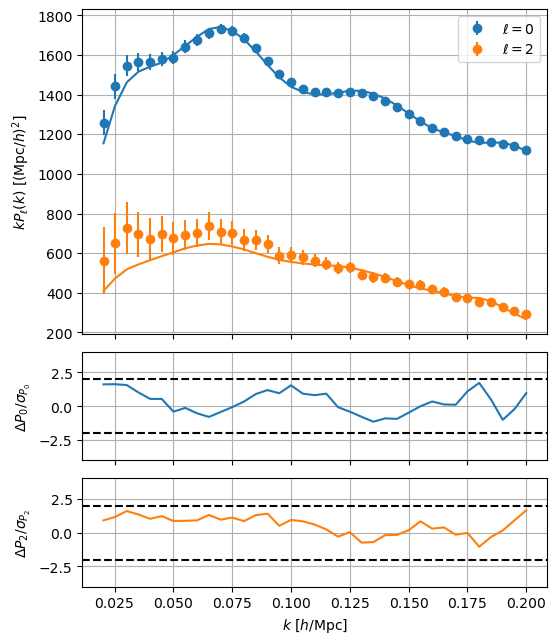

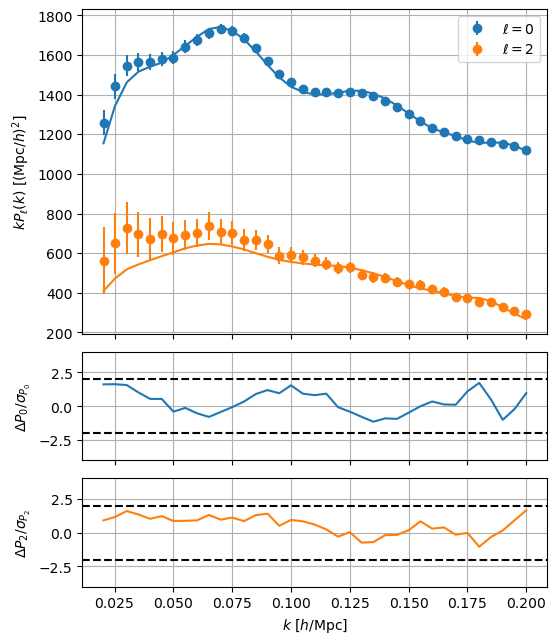

In [6]:

from desilike.samples import Chain
import matplotlib.pyplot as plt
from pathlib import Path
from desilike import setup_logging
setup_logging()

def load_chain(fi, burnin=0.3):
    from desilike.samples import Chain
    # chains = [Chain.load(ff).remove_burnin(burnin) for ff in fi]
    chains = [Chain.load(fi).remove_burnin(burnin)]
    chain = chains[0].concatenate(chains)
    print(f'chain: {chain}')
    return chain

# if args.plot_bestfit:
# chain_path = Path(f'{chain_name}.npy')
chain_path = Path('/global/homes/p/prakharb/FOLPSpipe/folps/chains/MCMC-fs_abacus2gen_folpsv2_fk_ps_0.201_Afull_false.npy')
chain = load_chain(chain_path)
likelihood(**chain.choice(index='argmax', input=True))
observables['LRG2']['ps'].plot(fn='test_bestfit.png',kw_save={'dpi':250})

